In [46]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [47]:
with open('Ames_Housing_Feature_Description.txt', 'r') as f:
  print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [48]:
df = pd.read_csv('Ames_outliers_removed.csv')

In [49]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [50]:
df = df.drop('PID', axis = 1)

In [51]:
len(df.columns)

80

In [52]:
100*df.isnull().sum() / len(df)

,0
MS SubClass,0.00000
MS Zoning,0.00000
Lot Frontage,16.74069
Lot Area,0.00000
Street,0.00000
...,...
Mo Sold,0.00000
Yr Sold,0.00000
Sale Type,0.00000
Sale Condition,0.00000


In [53]:
def percent_missing(df):
  percent_nun = 100*df.isnull().sum() / len(df)
  percent_nan = percent_nun[percent_nun > 0].sort_values()

  return percent_nan

In [54]:
percent_nan = percent_missing(df)
print(percent_nan)

Total Bsmt SF      0.034165
Bsmt Unf SF        0.034165
BsmtFin SF 2       0.034165
Electrical         0.034165
BsmtFin SF 1       0.034165
Garage Area        0.034165
Garage Cars        0.034165
Bsmt Full Bath     0.068329
Bsmt Half Bath     0.068329
Mas Vnr Area       0.785787
Bsmt Qual          2.733174
Bsmt Cond          2.733174
BsmtFin Type 1     2.733174
BsmtFin Type 2     2.767339
Bsmt Exposure      2.835668
Garage Type        5.363854
Garage Qual        5.432183
Garage Finish      5.432183
Garage Cond        5.432183
Garage Yr Blt      5.432183
Lot Frontage      16.740690
Fireplace Qu      48.582166
Mas Vnr Type      60.642296
Fence             80.457807
Alley             93.235395
Misc Feature      96.412709
Pool QC           99.590024
dtype: float64


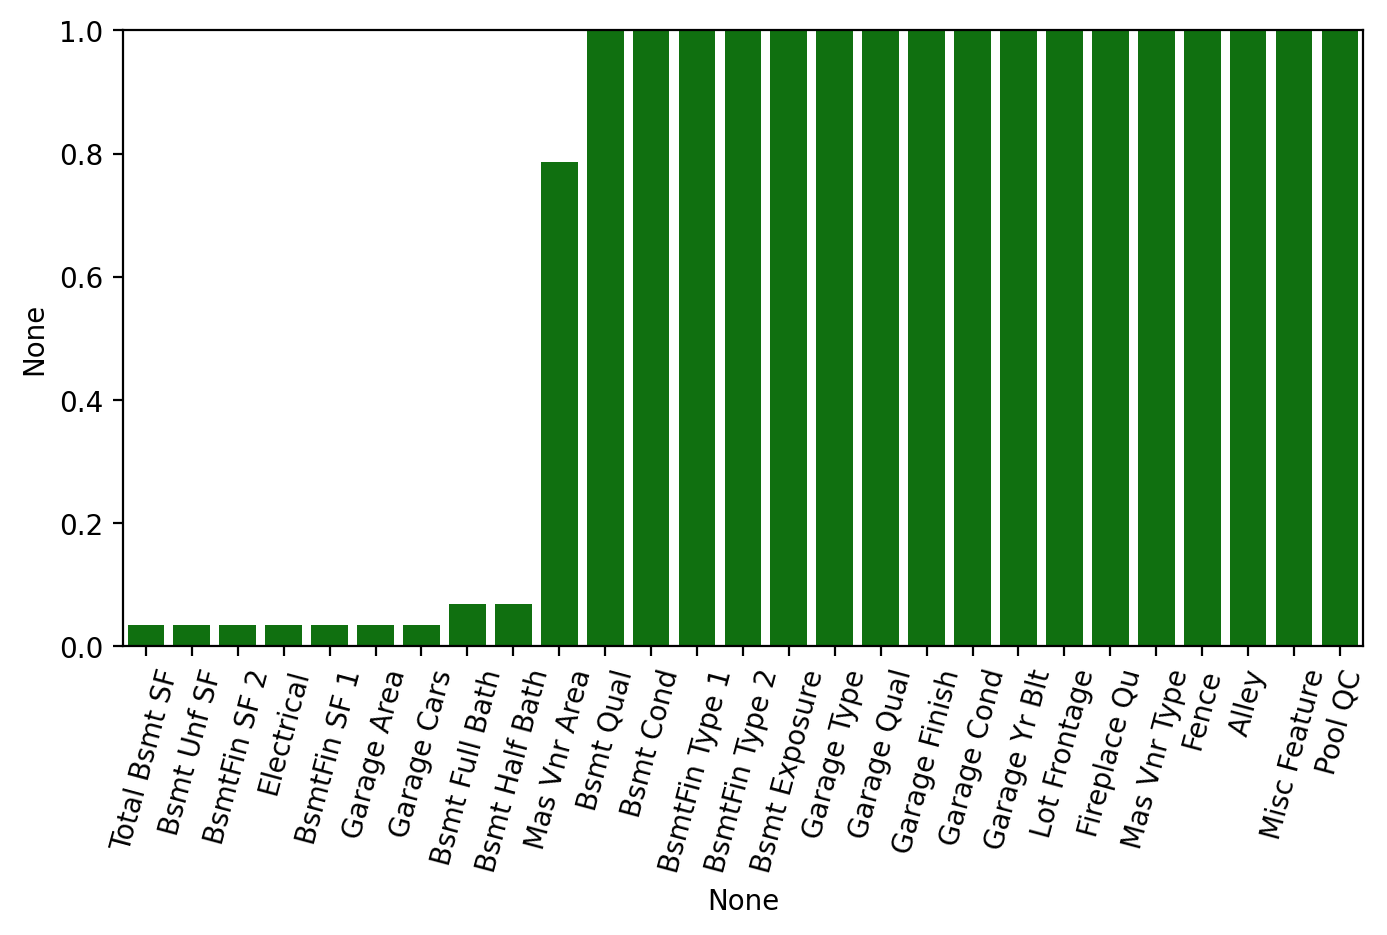

In [55]:
plt.figure(figsize= (8,4), dpi = 200)
sns.barplot(x = percent_nan.index, y = percent_nan, color = 'green')
plt.xticks(rotation = 75)
plt.ylim(0,1);

In [56]:
percent_nan[percent_nan < 1]

,0
Total Bsmt SF,0.034165
Bsmt Unf SF,0.034165
BsmtFin SF 2,0.034165
Electrical,0.034165
BsmtFin SF 1,0.034165
Garage Area,0.034165
Garage Cars,0.034165
Bsmt Full Bath,0.068329
Bsmt Half Bath,0.068329
Mas Vnr Area,0.785787


In [57]:
100/ len(df)

0.0341646737273659

In [58]:
df[df['Electrical'].isnull()]['Garage Area']

,Garage Area
1576,400.0


In [59]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [60]:
df = df.dropna(axis = 0, subset= ['Electrical', 'Garage Cars'])

In [61]:
percent_nan = percent_missing(df)

In [62]:
percent_nan[percent_nan< 1]

,0
Total Bsmt SF,0.034188
Bsmt Unf SF,0.034188
BsmtFin SF 2,0.034188
BsmtFin SF 1,0.034188
Bsmt Full Bath,0.068376
Bsmt Half Bath,0.068376
Mas Vnr Area,0.786325


In [63]:
100 / len(df)

0.03418803418803419

In [64]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [65]:
df[df['Bsmt Full Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [66]:
df[df['Bsmt Unf SF'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


In [67]:
# BSMT numeric column --> fillna 0
bsmt_num_col = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
df[bsmt_num_col] = df[bsmt_num_col].fillna(0)

# BSMT string col

bsmt_str_col = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
df[bsmt_str_col] = df[bsmt_str_col].fillna('None')


In [68]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


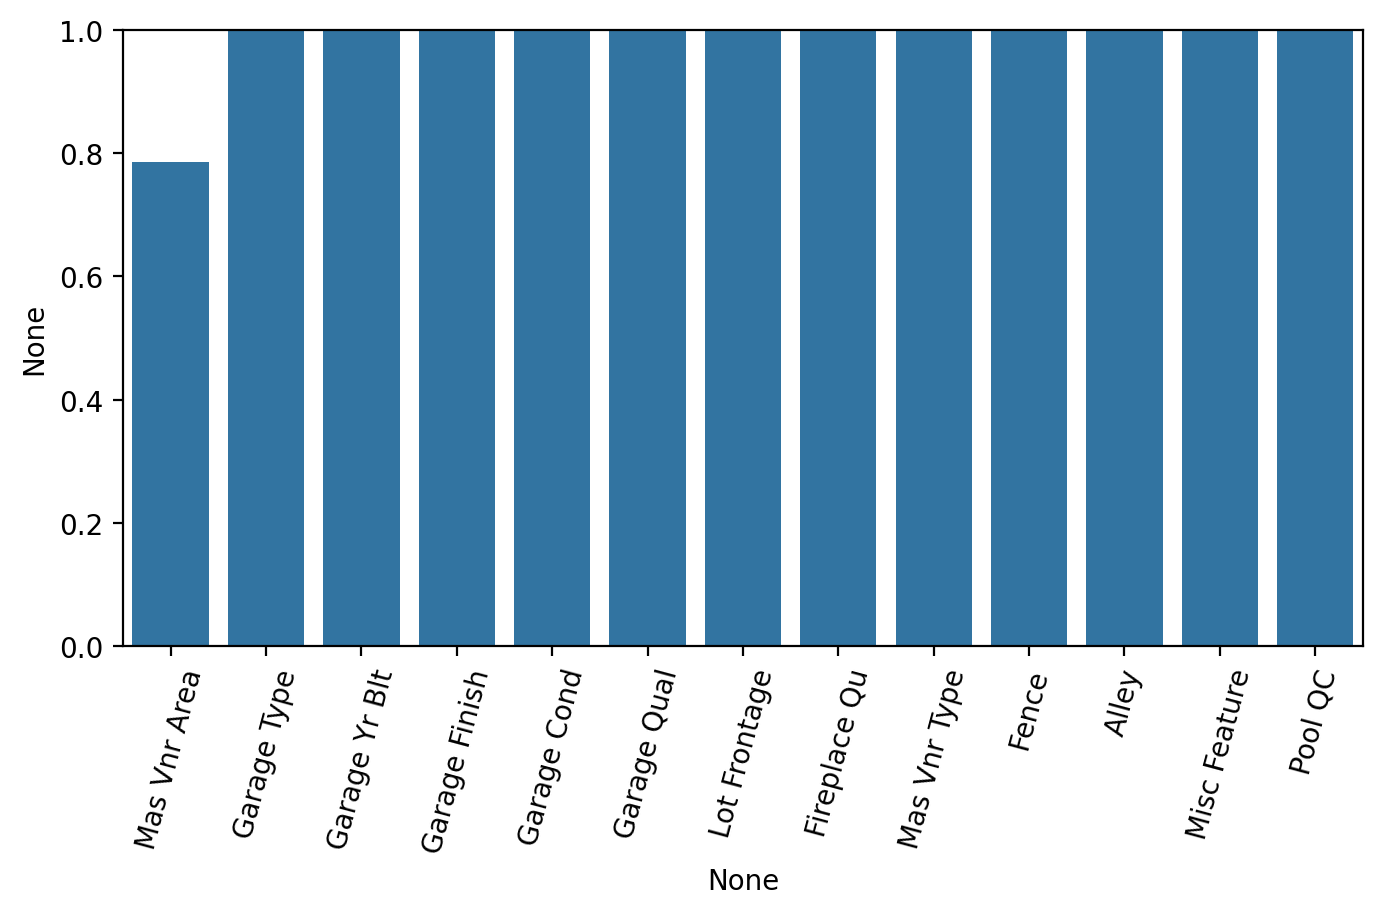

In [69]:
percent_nan = percent_missing(df)

plt.figure(figsize= (8,4), dpi = 200)
sns.barplot(x = percent_nan.index, y = percent_nan)
plt.xticks(rotation = 75)
plt.ylim(0,1);

In [70]:
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna('None')

In [71]:
gar_str_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']

In [72]:
df[gar_str_cols] = df[gar_str_cols].fillna('None')

In [73]:
percent_nan = percent_missing(df)

In [74]:
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [75]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna(0)

In [76]:
 df = df.drop(['Pool QC', 'Misc Feature', 'Alley', 'Fence'], axis = 1)

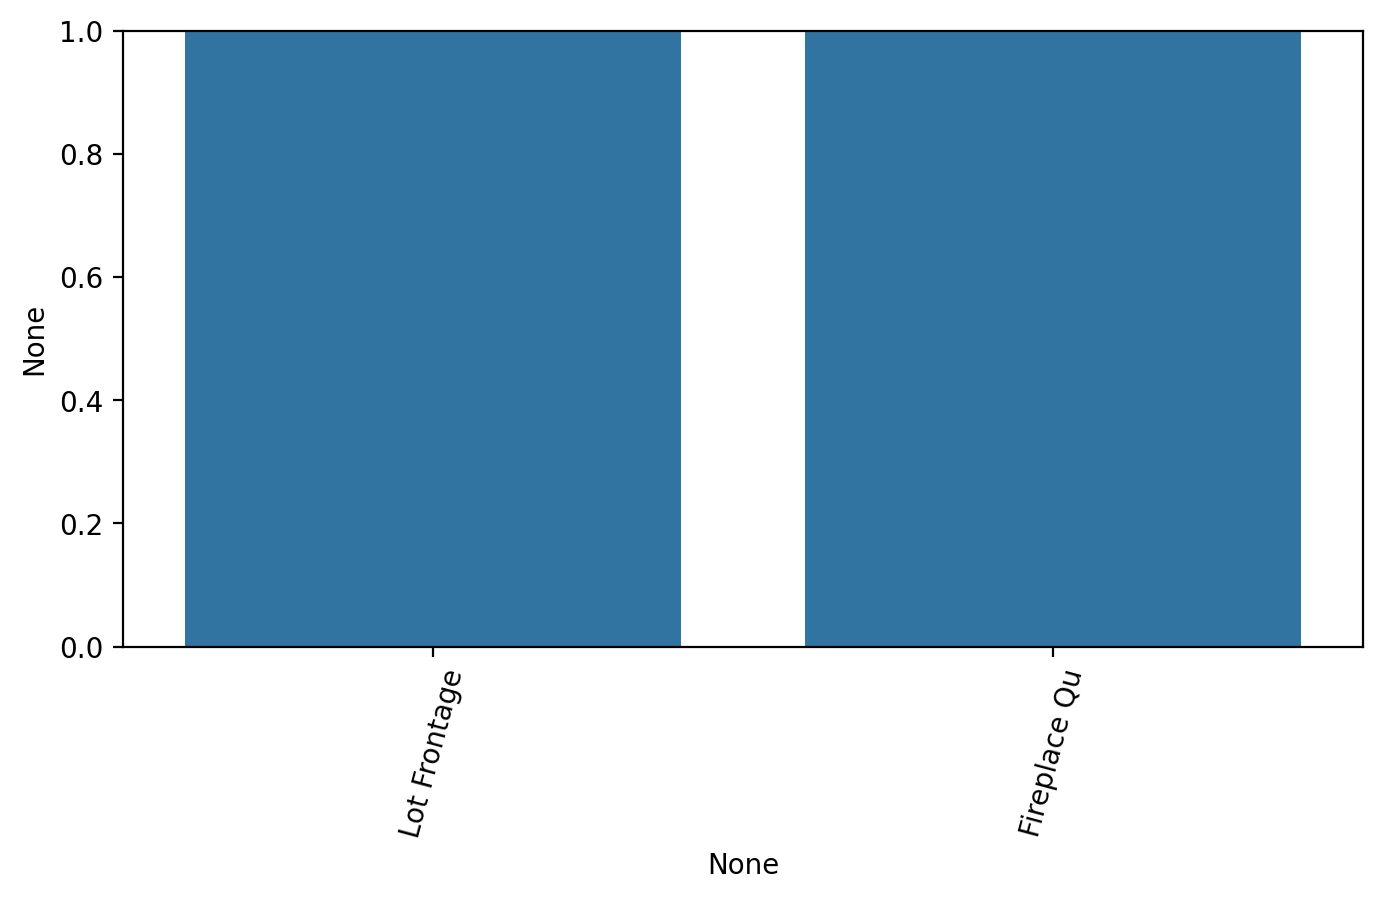

In [77]:
percent_nan = percent_missing(df)

plt.figure(figsize= (8,4), dpi = 200)
sns.barplot(x = percent_nan.index, y = percent_nan)
plt.xticks(rotation = 75)
plt.ylim(0,1);

In [80]:
df['Fireplace Qu'].value_counts()

,count
Fireplace Qu,
None,1420
Gd,741
TA,600
Fa,75
Po,46
Ex,43


In [79]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

<Axes: xlabel='Lot Frontage', ylabel='Neighborhood'>

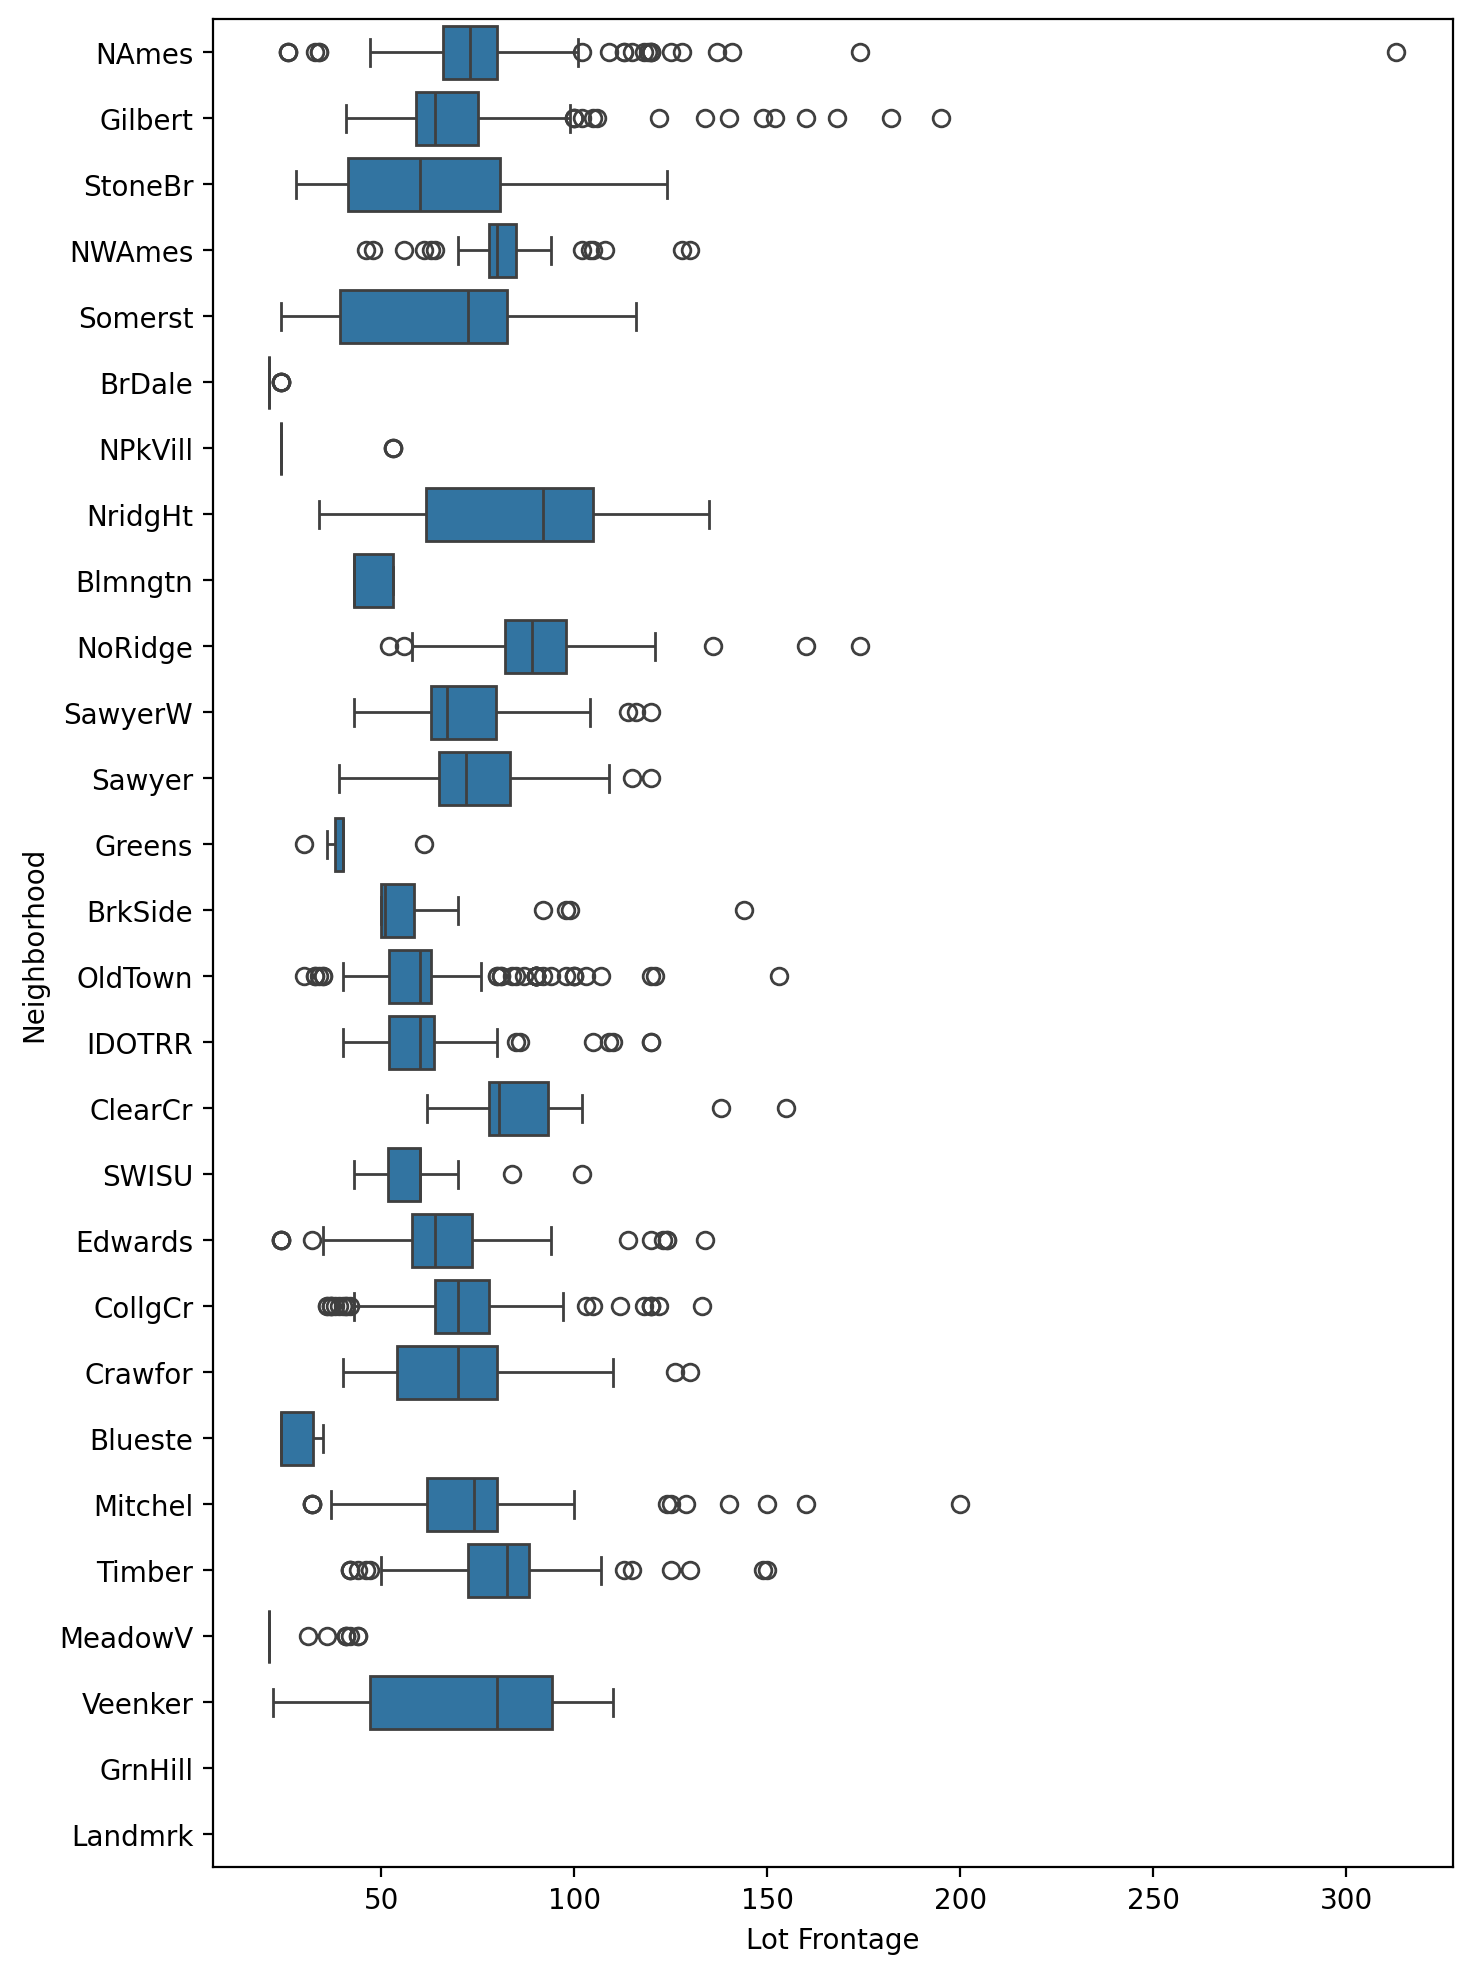

In [83]:
plt.figure(figsize = (8,12), dpi = 200)
sns.boxplot(x = 'Lot Frontage', y = 'Neighborhood', data = df)

In [89]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda value : value.fillna(value.mean()))

In [90]:
df.isnull().sum()

,0
MS SubClass,0
MS Zoning,0
Lot Frontage,3
Lot Area,0
Street,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [91]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(0)

In [92]:
df.isnull().sum()

,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
Lot Area,0
Street,0
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0
